In [1]:
import os
import cv2
import sklearn
import pandas as pd
import numpy as np,random
import seaborn as sn
import tensorflow as tf
from sklearn.svm import SVC
from keras.optimizers import Adam
from sklearn.utils import shuffle
from sklearn.svm import LinearSVC
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization,MaxPooling2D,Conv2D,Flatten,Dense,Dropout


In [2]:
path_of_dir=os.listdir('../brain tumor/')
classes_in_dir={'Healthy':0,'Brain Tumor':1}

classes_in_dir

{'Healthy': 0, 'Brain Tumor': 1}

In [105]:
import cv2
import numpy as np

def safe_augment(img):
    h, w = img.shape[:2]

    # 1. Fixed rotation (e.g., 5 degrees)
    angle = 5
    M_rot = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Fixed zoom (e.g., 1.05x)
    zf = 1.05
    zh, zw = int(h*zf), int(w*zf)
    img = cv2.resize(img, (zw, zh))
    start_y = max((zh - h)//2, 0)
    start_x = max((zw - w)//2, 0)
    img = img[start_y:start_y+h, start_x:start_x+w]

    # 3. Fixed brightness (+10)
    beta = 10
    img = cv2.convertScaleAbs(img, alpha=1.0, beta=beta)

    # 4. Fixed gamma (1.05)
    gamma = 1.05
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    # 5. Always apply Gaussian blur
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # 6. Always flip horizontally
    img = cv2.flip(img, 1)

    return img



X, Y = [], []

for i in classes_in_dir:
    path = '../brain tumor/' + i
    for j in os.listdir(path):
        pic = cv2.imread(path + '/' + j, cv2.IMREAD_GRAYSCALE)  # Force grayscale
        pic = cv2.resize(pic, (200, 200))                       # Force size
        pic = safe_augment(pic)
        pic = np.array(pic, dtype='float32')
        if pic.shape != (200, 200):
            pic = cv2.resize(pic, (200, 200))

        X.append(pic)
        Y.append(classes_in_dir[i])

       


In [106]:
x = np.array(X, dtype='float32').reshape(-1, 200, 200, 1) / 255.0  # normalize
y = np.array(Y)
x, y = shuffle(x, y, random_state=42)

In [107]:
pd.Series(y).value_counts()

0    2500
1    2500
Name: count, dtype: int64

In [108]:
y.shape

(5000,)

In [109]:
x.shape

(5000, 200, 200, 1)

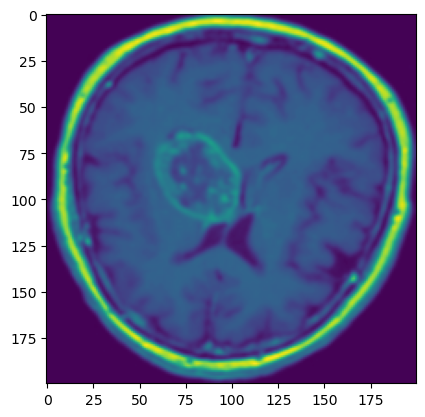

In [110]:
plt.imshow(x[1])


In [111]:
x.shape

(5000, 200, 200, 1)

In [112]:
x_train3D,x_test3D,y_train3D,y_test3D=train_test_split(x ,y,random_state=42,test_size=0.20)

Text(0.5, 0, '0')

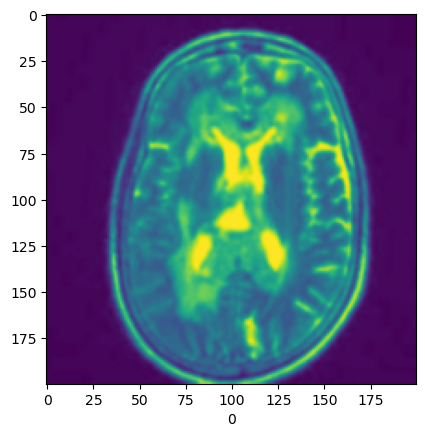

In [113]:
plt.imshow(x_test3D[5])
plt.xlabel(y_test3D[5])


In [114]:
x_train3D.shape

(4000, 200, 200, 1)

#CNN MODEL

In [115]:
cnn=Sequential([keras.layers.Input(shape=(200,200,1)),
Conv2D(filters=32, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Conv2D(filters=64, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Flatten(),
Dense(1, activation='sigmoid')

])

cnn.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 198, 198, 32)      320       
                                                                 
 batch_normalization_4 (Batc  (None, 198, 198, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 99, 99, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 97, 97, 64)        18496     
                                                                 
 batch_normalization_5 (Batc  (None, 97, 97, 64)       256       
 hNormalization)                                                 
                                                      

In [116]:
cnn.compile(optimizer=Adam(learning_rate=1e-4),loss='binary_crossentropy', metrics=['accuracy'])

In [117]:
cnn.fit(x_train3D,y_train3D,validation_data=(x_test3D,y_test3D), epochs=3, batch_size=16)

Epoch 1/3
250/250 [==============================] - 76s 300ms/step - loss: 0.4955 - accuracy: 0.8255 - val_loss: 0.5278 - val_accuracy: 0.8260
Epoch 2/3
250/250 [==============================] - 74s 297ms/step - loss: 0.1480 - accuracy: 0.9465 - val_loss: 0.2909 - val_accuracy: 0.8820
Epoch 3/3
250/250 [==============================] - 73s 293ms/step - loss: 0.0749 - accuracy: 0.9728 - val_loss: 0.2302 - val_accuracy: 0.9200


In [121]:
test_loss,test_acc=cnn.evaluate(x_test3D,y_test3D,verbose=2)

32/32 - 5s - loss: 0.2302 - accuracy: 0.9200 - 5s/epoch - 148ms/step


In [122]:
pred1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()

32/32 [==============================] - 5s 139ms/step


In [123]:
print(pred1[0:20])

[0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 1 0 1]


In [124]:
accuracy_score(y_test3D,pred1)

0.92

In [20]:
conf_mat= confusion_matrix(y_test3D,pred1)
print(classification_report(y_test3D,pred1))


              precision    recall  f1-score   support

           0       0.92      0.95      0.93       476
           1       0.95      0.93      0.94       524

    accuracy                           0.94      1000
   macro avg       0.93      0.94      0.93      1000
weighted avg       0.94      0.94      0.94      1000



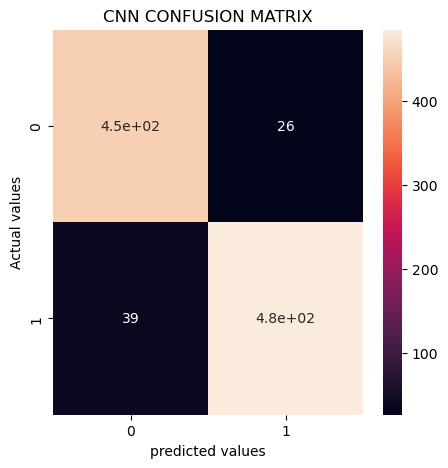

In [21]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("CNN CONFUSION MATRIX")
plt.show()

#Random forest

In [22]:
x_updated=x.reshape(len(x),-1)

In [23]:
x_updated.shape

(5000, 40000)

In [24]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_updated)

In [25]:
x_train2D,x_test2D,y_train2D,y_test2D=train_test_split(x_scaled,y,random_state=42,test_size=0.20)

In [26]:
x_train2D.shape

(4000, 40000)

In [27]:
rf=RandomForestClassifier()
rf.fit(x_train2D, y_train2D)

RandomForestClassifier()

In [28]:
pred2=rf.predict(x_test2D)

In [29]:
accuracy_score(y_test2D,pred2)

0.943

In [30]:

conf_mat2=confusion_matrix(y_test2D,pred2)


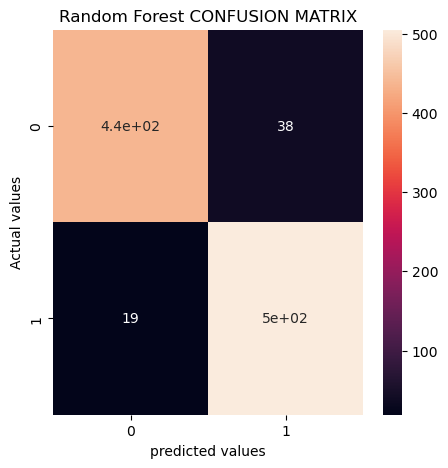

In [31]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Random Forest CONFUSION MATRIX")
plt.show()

#SVM

In [141]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC

pipeline = Pipeline([
    ('pca', PCA(n_components=1000)),        # reduce to 500 features
    ('svm', LinearSVC(C=1.0, max_iter=2000, tol=1e-3))  # fewer iterations needed
])

pipeline.fit(x_train2D, y_train2D)
pred3 = pipeline.predict(x_test2D)



In [142]:
accuracy_score(y_test2D,pred3)

0.914

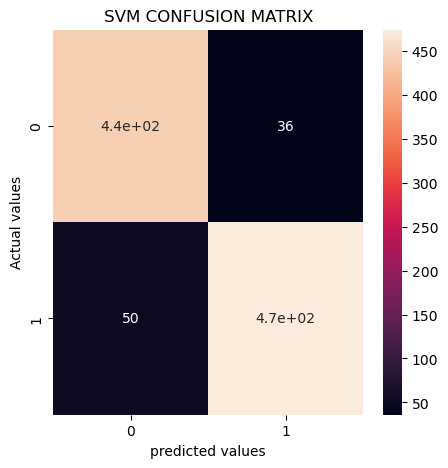

In [143]:
conf_mat3=confusion_matrix(y_test2D,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("SVM CONFUSION MATRIX")
plt.show()

#KNN

In [144]:
knn=KNeighborsClassifier(n_neighbors=2, weights='distance')
knn.fit(x_train2D,y_train2D)

KNeighborsClassifier(n_neighbors=2, weights='distance')

In [145]:
pred4=knn.predict(x_test2D)

In [146]:
#evaluting the model
accuracy_score(y_test2D,pred4)

0.968

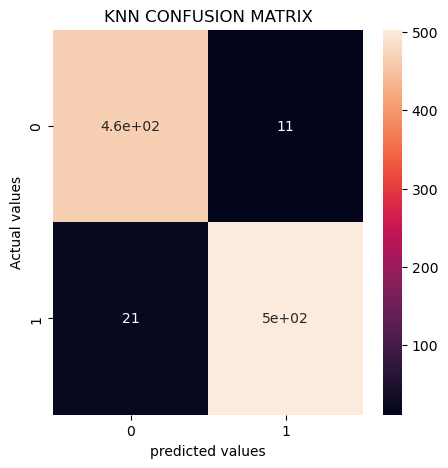

In [147]:
conf_mat4=confusion_matrix(y_test2D,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("KNN CONFUSION MATRIX")
plt.show()

#Logistic Regression

In [ ]:
LR = LogisticRegression(max_iter=10000, solver='lbfgs')
LR.fit(x_train2D, y_train2D)

In [41]:
pred5 = LR.predict(x_test2D)

print("Accuracy:", accuracy_score(y_test2D, pred5))
print("\nClassification Report:\n", classification_report(y_test2D, pred5))

Accuracy: 0.929

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93       476
           1       0.94      0.92      0.93       524

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



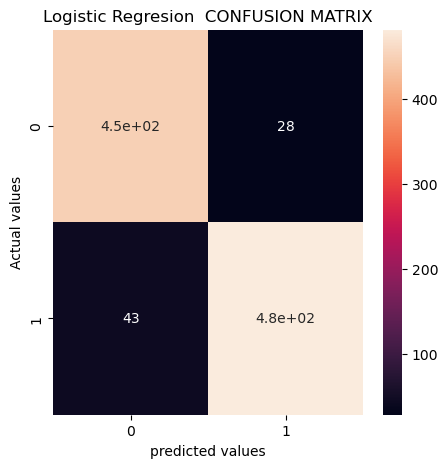

In [42]:
conf_mat5= confusion_matrix(y_test2D,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Logistic Regresion  CONFUSION MATRIX")
plt.show()

Text(0.5, 0, '1')

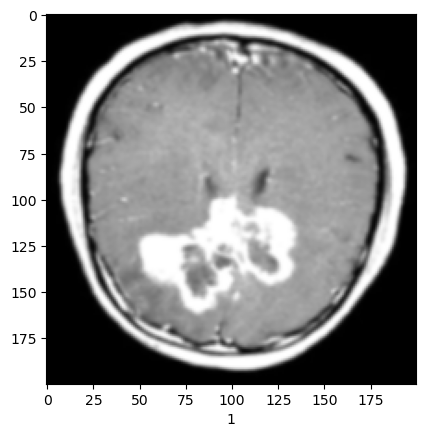

In [43]:
w=plt.imshow(x_test3D[50] ,cmap='gray')
plt.xlabel(y_test3D[50])

In [44]:
f=np.where(y_test3D != pred1)[0]

In [45]:
print(f[0:5])

[33 35 38 93 96]


In [46]:
print("Y_test =",y_test2D[103])

Y_test = 1


In [47]:
print("CNN =",pred1[103])

CNN = 1


In [48]:
print("RF =",pred2[103])

RF = 1


In [49]:
print("SVM =",pred3[103])

SVM = 1


In [50]:
print("KNN =",pred4[103])

KNN = 1


In [51]:
print("LR =",pred5[103])

LR = 1


# ALL PREDICTED VALUES

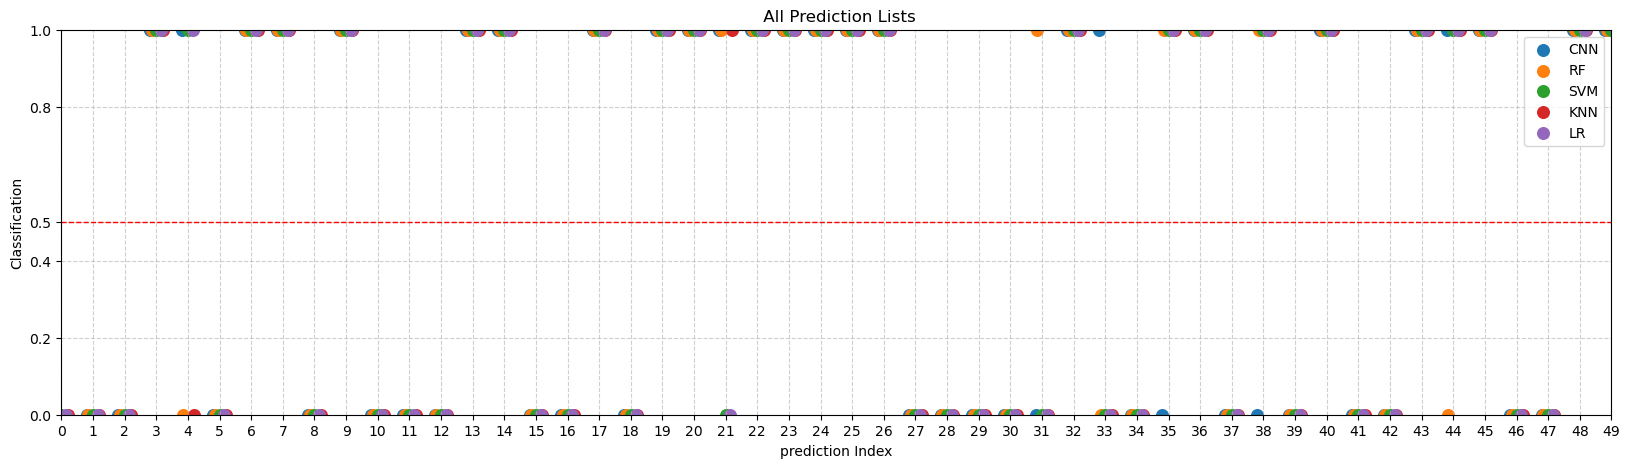

In [52]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=70)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=70)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=70)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=70)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=70)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,10)
plt.xticks(range(0,50))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [53]:
pp1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()
pp2=rf.predict(x_test2D)
pp3=svm.predict(x_test2D)
pp4=knn.predict(x_test2D)
pp5=LR.predict(x_test2D)

32/32 [==============================] - 4s 138ms/step


In [54]:
print(pp1[0:2])

[0 0]


In [55]:
total_prediction=[]
for i in range(len(pp3)):
    totaladd=pp1[i]+pp2[i]+pp3[i]+pp4[i]+pp5[i]
    total_prediction.append(totaladd)


In [56]:
Ensemble_prediction = [1 if val >= 3 else 0 for val in total_prediction]
print(Ensemble_prediction[:6])

[0, 0, 0, 1, 1, 0]


In [57]:
print(y_test3D[0:6])

[0 0 0 1 1 0]


In [58]:
print(pred1[0:6])

[0 0 0 1 1 0]


In [59]:
print(pred2[0:6])

[0 0 0 1 0 0]


In [60]:
print(pred3[0:6])

[0 0 0 1 1 0]


In [61]:
print(pred4[0:6])

[0 0 0 1 0 0]


In [62]:
print(pred5[0:6])

[0 0 0 1 1 0]


In [63]:
g=np.where(y_test3D != Ensemble_prediction)[0]
print(g[0:10])

[ 56  96 113 117 139 199 261 276 325 385]


In [64]:
print("Accuracy:", accuracy_score(y_test2D, Ensemble_prediction))
print("\nClassification Report:\n", classification_report(y_test2D, Ensemble_prediction))

Accuracy: 0.967

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97       476
           1       0.96      0.98      0.97       524

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



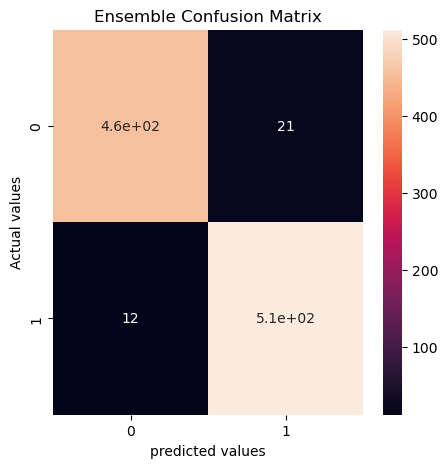

In [65]:
ensemble_confusion_matrix= confusion_matrix(y_test2D,Ensemble_prediction)
plt.figure(figsize=(5,5))
sn.heatmap(ensemble_confusion_matrix,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Ensemble Confusion Matrix")
plt.show()

(-0.5, 388.5, 438.5, -0.5)

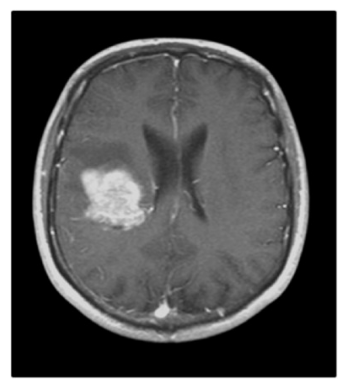

In [125]:
# Path to image
img_path = r"D:\My Final Work\external_pic\1.jpg"  # use raw string to avoid \n errors
# Read image
check_img1 = cv2.imread(img_path,1)
plt.imshow(check_img1)
plt.axis('off')





In [126]:
check_img = cv2.imread(img_path,0)
check_img=cv2.resize(check_img,(200,200))
check_img = safe_augment(check_img)

In [127]:
check_img.shape

(200, 200)

In [128]:
cnnpred1 = check_img.reshape(1, 200, 200, 1) 
cnnpred = cnnpred1 / 255.0   

In [129]:
cnnpred.shape

(1, 200, 200, 1)

In [130]:
p1=(cnn.predict(cnnpred)>0.5).astype('int').flatten()

1/1 [==============================] - 0s 39ms/step


In [131]:
print(p1)

[1]


# below is for 2D arrays

In [73]:
p_2D=cnnpred.reshape(1, -1)
p_2D.shape

(1, 40000)

In [74]:
p_2D=p_2D/255.0

In [75]:
p2=rf.predict(p_2D)

In [76]:
print(p2)

[0]


In [77]:
p3=svm.predict(p_2D)

In [78]:
print(p3)

[0]


In [79]:
p4=LR.predict(p_2D)

In [80]:
print(p4)

[0]


In [81]:
p5=knn.predict(p_2D)

In [82]:
print(p5)

[0]


In [83]:
if(p1+p2+p3+p4+p5 >= 3):
    print("Tumor")
elif (p1+p2+p3+p4+p5 < 3):
    print("No Tumor")


No Tumor
